SCVI Demo 2

April 23 2026.


- Understand how mathematical concepts translate into code
- Be able to manipulate latent space (t-SNE of mean + variance)
- Interpret plotting, latent space, and methods

### Libraries and Data
- scvi-tools
- anndata
- scanpy

In [1]:
!pip install --quiet scvi-colab
from scvi_colab import install
install()

INFO     scvi-colab: Installing scvi-tools.                                                                        
INFO     scvi-colab: Install successful. Testing import.                                                           


/usr/local/lib/python3.12/dist-packages/pyro/ops/stats.py:527: SyntaxWarning: invalid escape sequence '\g'
  we have :math:`ES^{*}(P,Q) \ge ES^{*}(Q,Q)` with equality holding if and only if :math:`P=Q`, i.e.


In [2]:
import os
import tempfile

import scanpy as sc
import scvi
import seaborn as sns
import torch
import pandas as pd

scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

# Connect to google drive
from google.colab import drive

drive.mount('/content/drive')
save_dir = '/content/drive/MyDrive/scvi_data'
os.makedirs(save_dir, exist_ok=True)

sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0


Last run with scvi-tools version: 1.4.2


In [6]:
adata = scvi.data.heart_cell_atlas_subsampled(save_path=save_dir)
adata

INFO     File /content/drive/MyDrive/scvi_data/hca_subsampled_20k.h5ad already downloaded                          


AnnData object with n_obs × n_vars = 18641 × 26662
    obs: 'NRP', 'age_group', 'cell_source', 'cell_type', 'donor', 'gender', 'n_counts', 'n_genes', 'percent_mito', 'percent_ribo', 'region', 'sample', 'scrublet_score', 'source', 'type', 'version', 'cell_states', 'Used'
    var: 'gene_ids-Harvard-Nuclei', 'feature_types-Harvard-Nuclei', 'gene_ids-Sanger-Nuclei', 'feature_types-Sanger-Nuclei', 'gene_ids-Sanger-Cells', 'feature_types-Sanger-Cells', 'gene_ids-Sanger-CD45', 'feature_types-Sanger-CD45', 'n_counts'
    uns: 'cell_type_colors'

In [7]:
adata

AnnData object with n_obs × n_vars = 18641 × 26662
    obs: 'NRP', 'age_group', 'cell_source', 'cell_type', 'donor', 'gender', 'n_counts', 'n_genes', 'percent_mito', 'percent_ribo', 'region', 'sample', 'scrublet_score', 'source', 'type', 'version', 'cell_states', 'Used'
    var: 'gene_ids-Harvard-Nuclei', 'feature_types-Harvard-Nuclei', 'gene_ids-Sanger-Nuclei', 'feature_types-Sanger-Nuclei', 'gene_ids-Sanger-Cells', 'feature_types-Sanger-Cells', 'gene_ids-Sanger-CD45', 'feature_types-Sanger-CD45', 'n_counts'
    uns: 'cell_type_colors'

### Preprocessing

In [8]:
# NORMALIZATION
adata.layers["counts"] = adata.X.copy()  # preserve counts since scvi-tools models require the raw counts (not log library size normalized)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata) # In scRNA-seq analysis, it’s popular to normalize the data for other tasks + visualization
adata.raw = adata  # freeze the state in `.raw`

In [9]:
# FEATURE SELECTION
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=1200,
    subset=True,
    layer="counts",
    flavor="seurat_v3",
    batch_key="cell_source", # within adata.obs
)

### Model

In [14]:
# If model has already been run, simply load
model_dir = os.path.join(save_dir, "scvi_model")
model = scvi.model.SCVI.load(model_dir, adata=adata)

INFO     File /content/drive/MyDrive/scvi_data/scvi_model/model.pt already downloaded                              


In [15]:
# If model has not been run, make

# Notify scvi-tools of data batches and annotations
# scvi.model.SCVI.setup_anndata(
#     adata,
#     layer="counts", # we use the raw counts we preserved
#     # declare these covariates so they are NOT learned as latent var
#     categorical_covariate_keys=["cell_source", "donor"],
#     continuous_covariate_keys=["percent_mito", "percent_ribo"],
# )
# model = scvi.model.SCVI(adata)
# model.train(train_size=0.8, check_val_every_n_epoch=1)
# model_dir = os.path.join(save_dir, "scvi_model")
# model.save(model_dir, overwrite=True)

We now have an scVI model following [scvi.model.SCVI](https://docs.scvi-tools.org/en/1.3.3/api/reference/scvi.model.SCVI.html#scvi.model.SCVI).

In [16]:
model

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False

In [26]:
model.adata

AnnData object with n_obs × n_vars = 18641 × 1200
    obs: 'NRP', 'age_group', 'cell_source', 'cell_type', 'donor', 'gender', 'n_counts', 'n_genes', 'percent_mito', 'percent_ribo', 'region', 'sample', 'scrublet_score', 'source', 'type', 'version', 'cell_states', 'Used', '_scvi_batch', '_scvi_labels'
    var: 'gene_ids-Harvard-Nuclei', 'feature_types-Harvard-Nuclei', 'gene_ids-Sanger-Nuclei', 'feature_types-Sanger-Nuclei', 'gene_ids-Sanger-Cells', 'feature_types-Sanger-Cells', 'gene_ids-Sanger-CD45', 'feature_types-Sanger-CD45', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'cell_type_colors', 'log1p', 'hvg', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs'
    layers: 'counts'

#### Training Loss Curves using attribute `model.history`

In [20]:
import matplotlib.pyplot as plt
hist = model.history
def plot_metric(train_key, val_key, title, ylabel, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
        show_plot = True
    else:
        show_plot = False

    if train_key in hist and not hist[train_key].empty:
        # Assuming hist[key] is a DataFrame with the metric in the first column and epoch in index
        ax.plot(hist[train_key].index, hist[train_key].iloc[:, 0], label="train")
    if val_key in hist and not hist[val_key].empty:
        ax.plot(hist[val_key].index, hist[val_key].iloc[:, 0], label="validation")

    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    if show_plot:
        plt.tight_layout()
        plt.show()

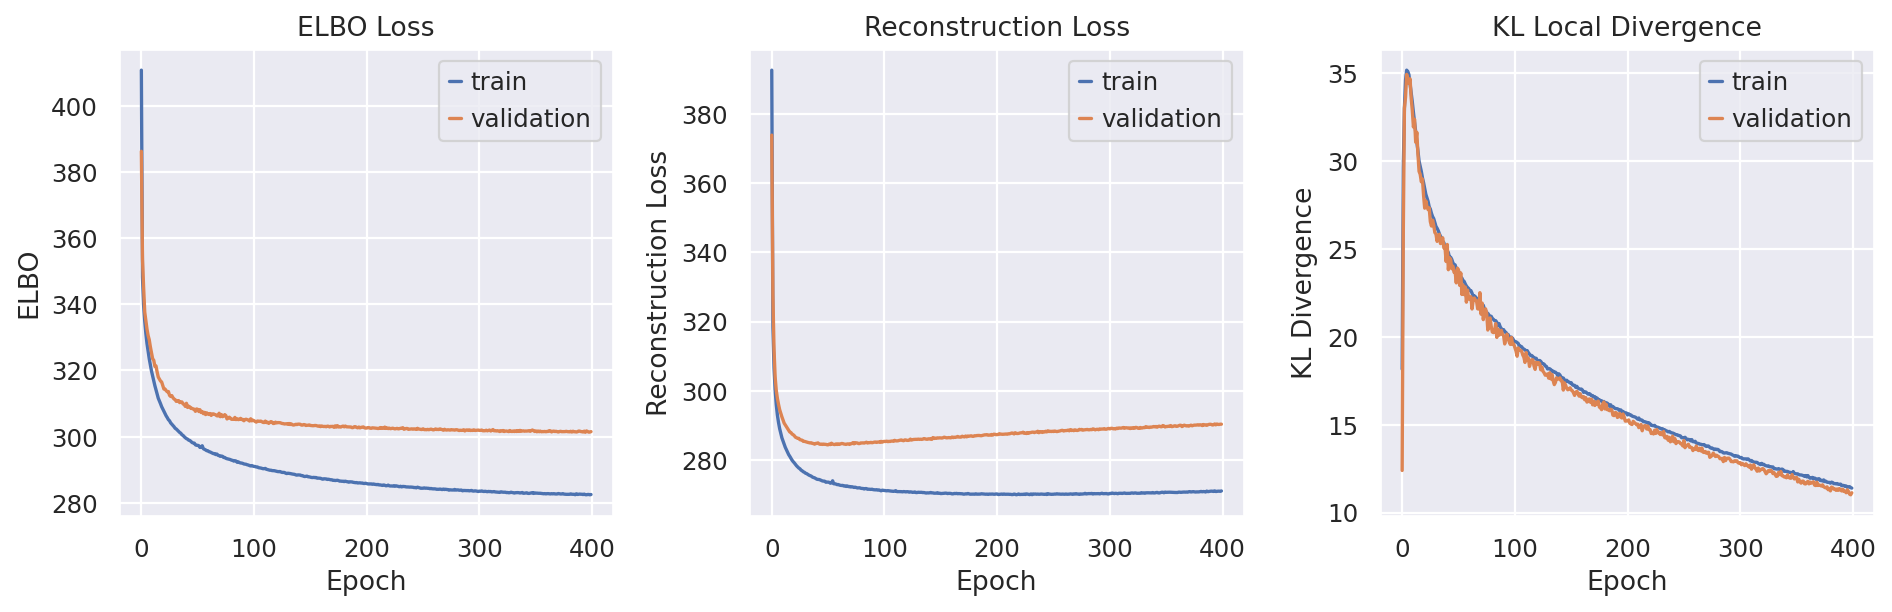

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

plot_metric("elbo_train", "elbo_validation", "ELBO Loss", "ELBO", ax=axes[0])
plot_metric("reconstruction_loss_train", "reconstruction_loss_validation", "Reconstruction Loss", "Reconstruction Loss", ax=axes[1])
plot_metric("kl_local_train", "kl_local_validation", "KL Local Divergence", "KL Divergence", ax=axes[2])

plt.tight_layout()
plt.show()

In [30]:
elbo = model.get_elbo(adata)
elbo # -283.5590 was minimized (bc negative) during training

tensor(-283.5590)

In [50]:
reconstruction = model.get_reconstruction_error(adata)
reconstruction # 272.3427 was maximized during training

{'reconstruction_loss': tensor(272.3427)}

In [51]:
marginal_ll = model.get_marginal_ll(adata)
marginal_ll

KeyboardInterrupt: 

#### Latent Space (z) using model method `get_latent_representation`

Essentially, we have simplified 26,662 genes --> 1200 highly variable genes --> 10 latent variables.

In [35]:
latent = model.get_latent_representation(return_dist=True)
# return_dist gets both mean and variance
# tuple of two arrays size (n_obs, n_latent) with the mean and variance of the latent distribution

In [45]:
adata.obsm["X_scVI"] = latent[0]
adata.obsm["var_scVI"] = latent[1]

In [54]:
means = pd.DataFrame(latent[0])
means.columns = [f"z_{i}" for i in range(10)]
means.index = adata.obs_names
means.head()

,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7,z_8,z_9
AACTCCCCACGAGAGT-1-HCAHeart7844001,1.636962,0.703735,0.431964,0.372073,-0.108176,-1.548789,0.643804,0.079262,2.116787,0.475718
ATAACGCAGAGCTGGT-1-HCAHeart7829979,0.174487,-0.165281,-0.454838,-0.088036,-0.166737,-0.738795,1.166762,1.596600,-0.168094,-0.121761
GTCAAGTCATGCCACG-1-HCAHeart7702879,1.069845,1.092440,-0.383536,0.679869,0.450139,-0.739805,-1.560726,-0.804553,-0.335870,-0.036982
GGTGATTCAAATGAGT-1-HCAHeart8102858,-0.305304,0.693655,0.807918,0.231564,1.183794,-0.800057,-1.098605,-0.037679,0.217569,-1.010099
AGAGAATTCTTAGCAG-1-HCAHeart8102863,1.642348,2.386396,1.632222,-1.418426,0.455585,0.326564,-0.213403,1.431176,-3.919601,0.323430


#### Gene space using model method `get_normalized_expression`
Batch correction would be performed to get a harmonized expression (default is decoding per-batch).

If we wanted to do this, we could add `batch_key="cell_source"` to `scvi.model.SCVI.setup_anndata` and then pass `transform_batch=['Harvard-Nuclei', 'Sanger-CD45', 'Sanger-Cells', 'Sanger-Nuclei']` to `model.get_normalized_expression`. This would take an average.

But that also requires prioritizing one of the covariates. If we don't want to, we can simply not do this — each cell would be decoded using its own observed covariates. This problem does not come up for fetching the latent space.


In [94]:
# NO BATCH CORRECTION
denoised = model.get_normalized_expression(adata, library_size=1e4)
# Store as a layer
adata.layers["scvi_normalized"] = model.get_normalized_expression(library_size=10e4)

#### Plotting UMAP with `scanpy.pl.umap`

In [102]:
# PCA and UMAP plots on non-batch corrected data (get_normalized_expression)
# Nuisance variation is creating an unclean separation
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=20)
sc.tl.umap(adata, min_dist=0.3)

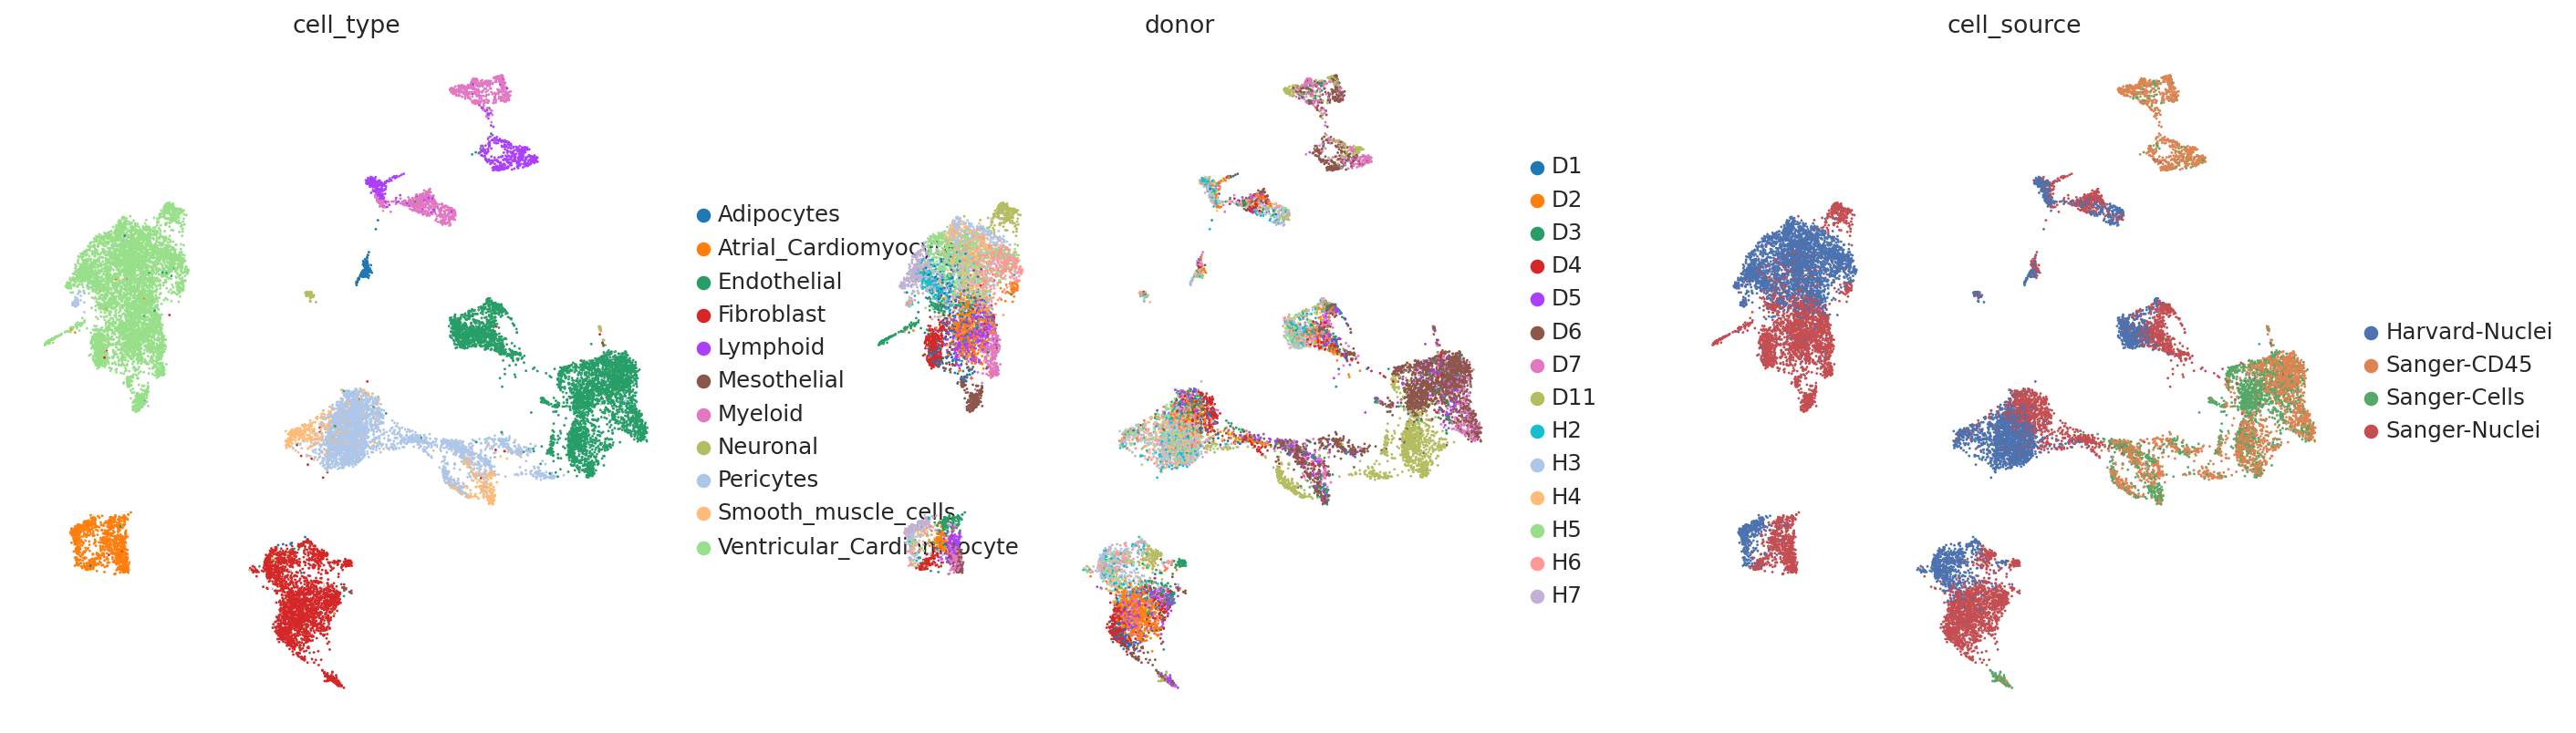

In [105]:
sc.pl.umap(adata, color=["cell_type", "donor", "cell_source"], ncols=3, frameon=False)

In [ ]:
# PCA and UMAP plots on batch-corrected data (get_latent_representation)
# Much better separation

In [106]:
sc.pp.neighbors(adata, use_rep="X_scVI") # Using means of latent space z
sc.tl.umap(adata, min_dist=0.3)

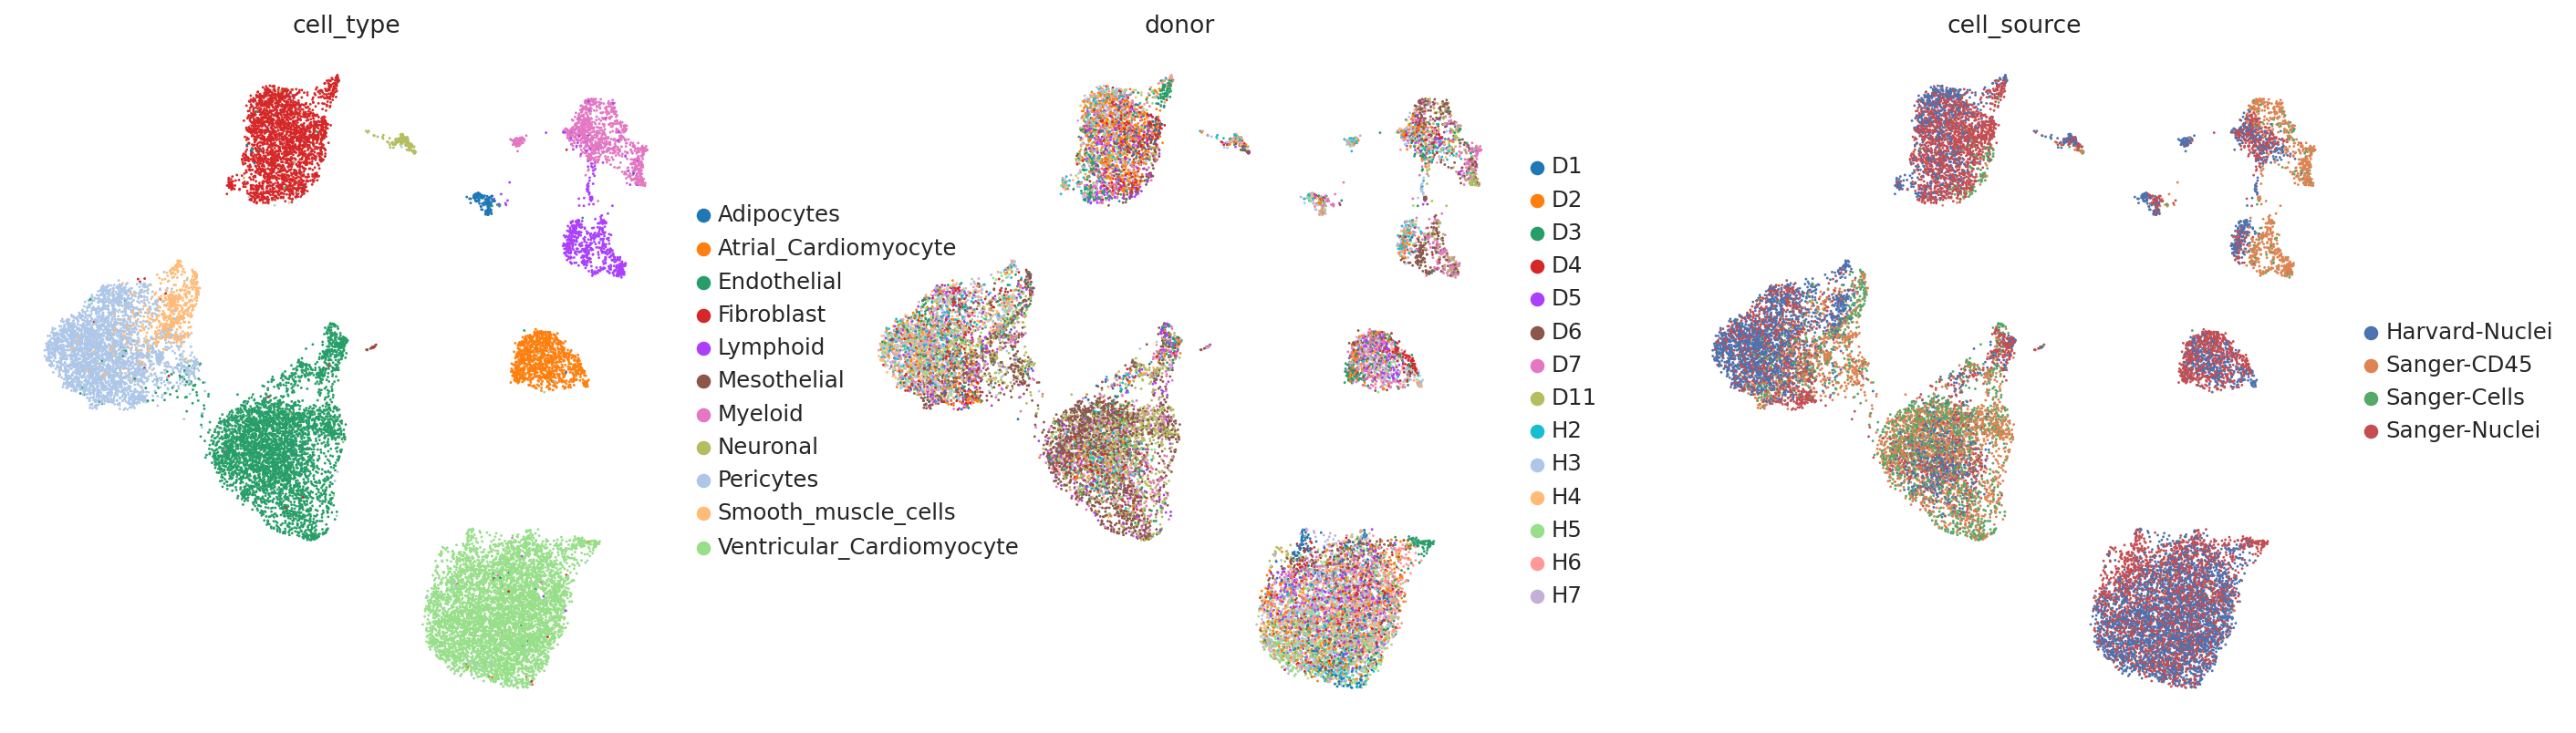

In [107]:
sc.pl.umap(adata, color=["cell_type", "donor", "cell_source"], ncols=3, frameon=False)

In [108]:
# Leiden clusters instead of annotated data (cell_type), similar results
SCVI_CLUSTERS_KEY = "leiden_scVI"
sc.tl.leiden(adata, key_added=SCVI_CLUSTERS_KEY, resolution=0.5)

/tmp/ipykernel_4059/1040911179.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, key_added=SCVI_CLUSTERS_KEY, resolution=0.5)


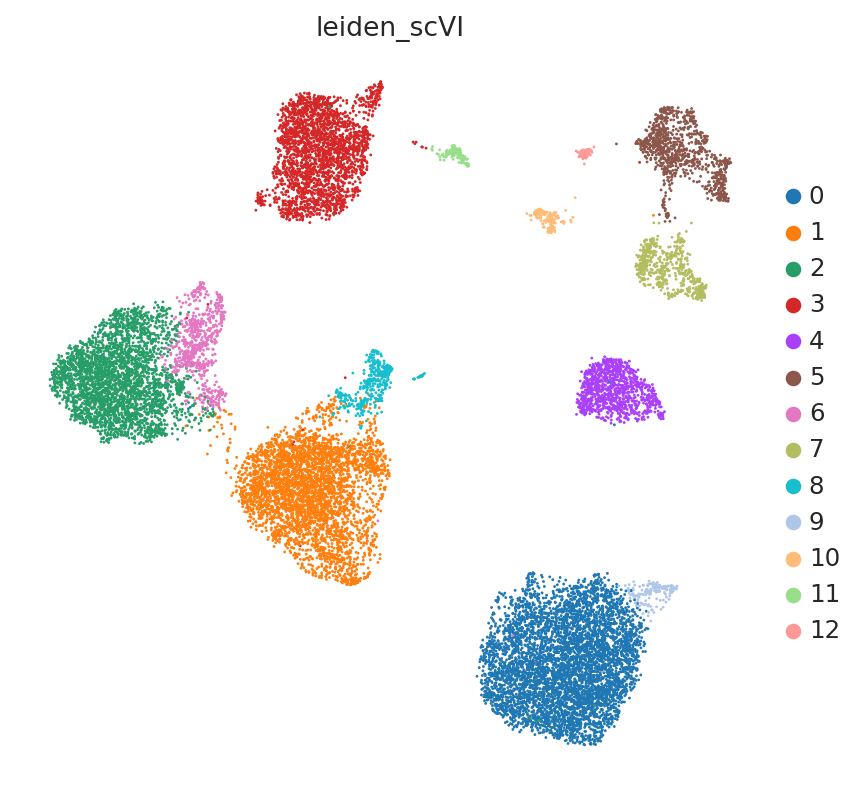

In [109]:
sc.pl.umap(adata, color=[SCVI_CLUSTERS_KEY], frameon=False)

#### Plotting t-SNE with `scanpy.pl.umap`

In [111]:
sc.tl.tsne(adata, use_rep="X_scVI", perplexity=10, n_jobs=-1) # Using means of latent space z, less perplexity, and parallelize

/tmp/ipykernel_4059/1308621613.py:1: UserWarning: In previous versions of scanpy, calling tsne with `n_jobs` > 1 would use MulticoreTSNE. Now this uses the scikit-learn version of TSNE by default. If you’d like the old behaviour (which is deprecated), pass `use_fast_tsne=True`. Note, MulticoreTSNE is not actually faster anymore.
  sc.tl.tsne(adata, use_rep="X_scVI", perplexity=10, n_jobs=-1) # Using means of latent space z, less perplexity, and parallelize


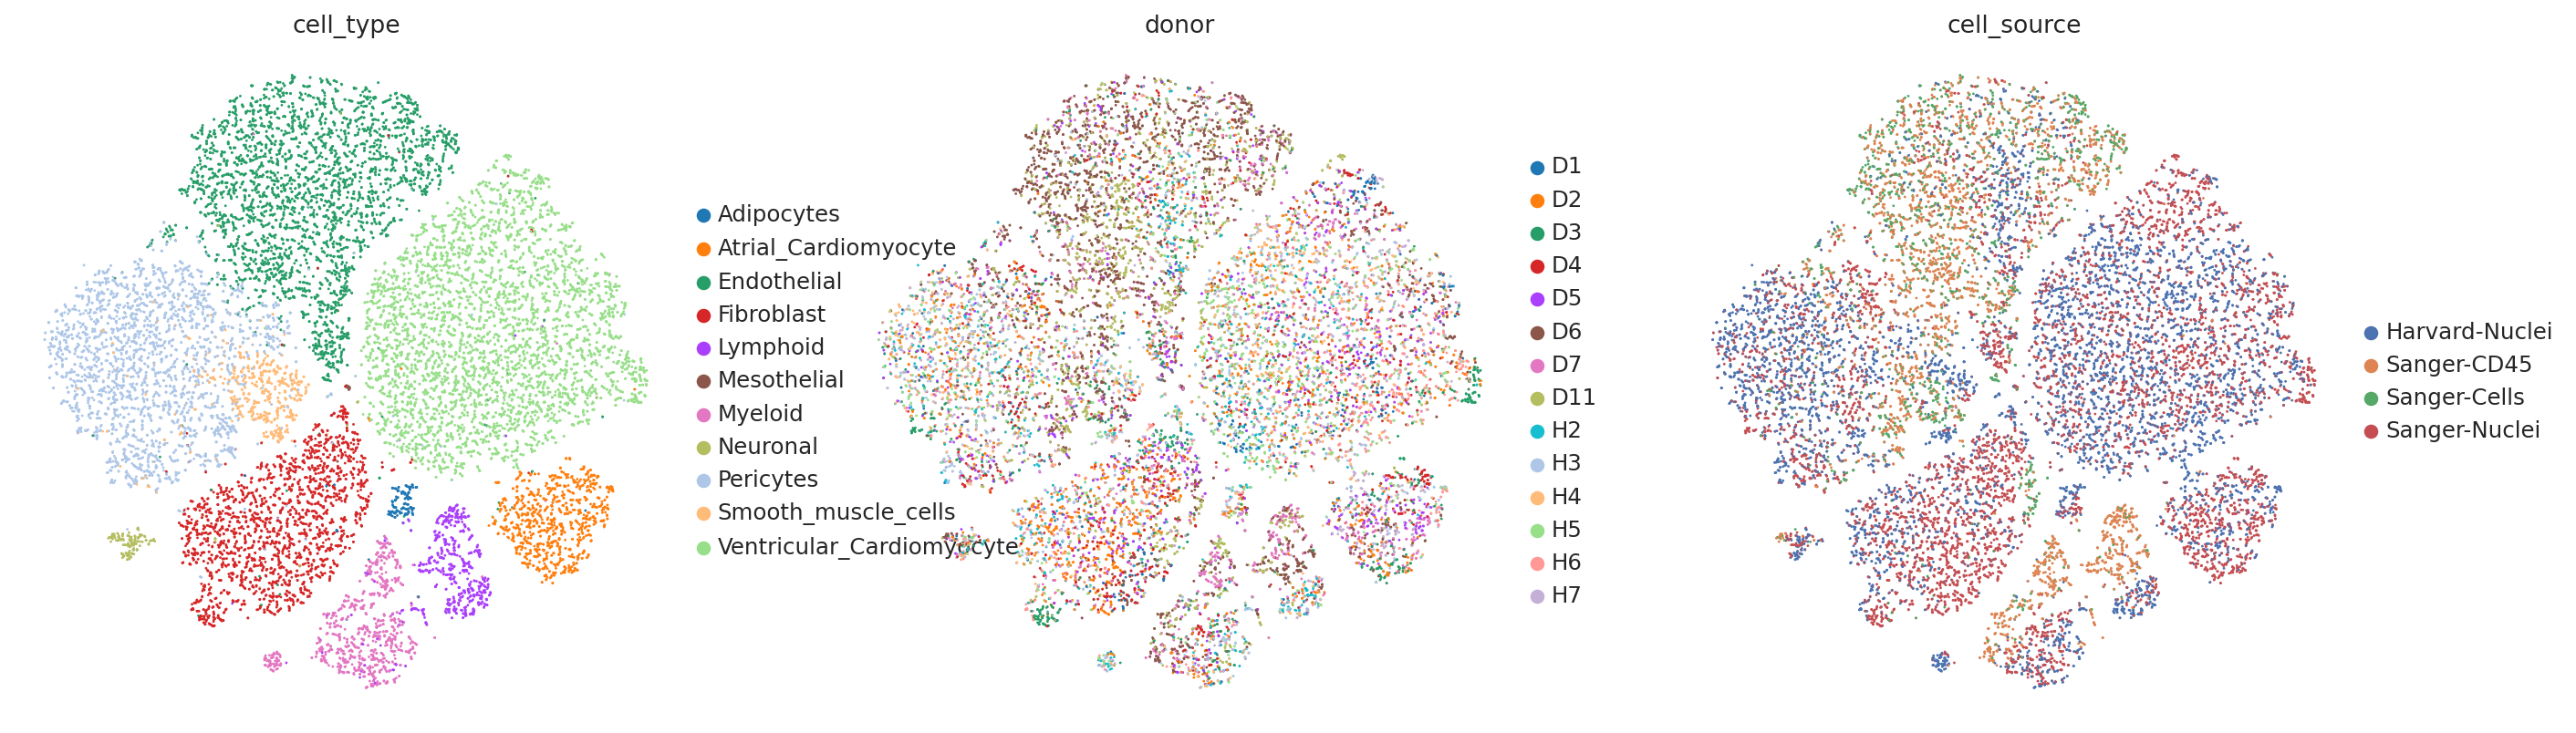

In [114]:
sc.pl.tsne(adata, color=["cell_type", "donor", "cell_source"], ncols=3, frameon=False)

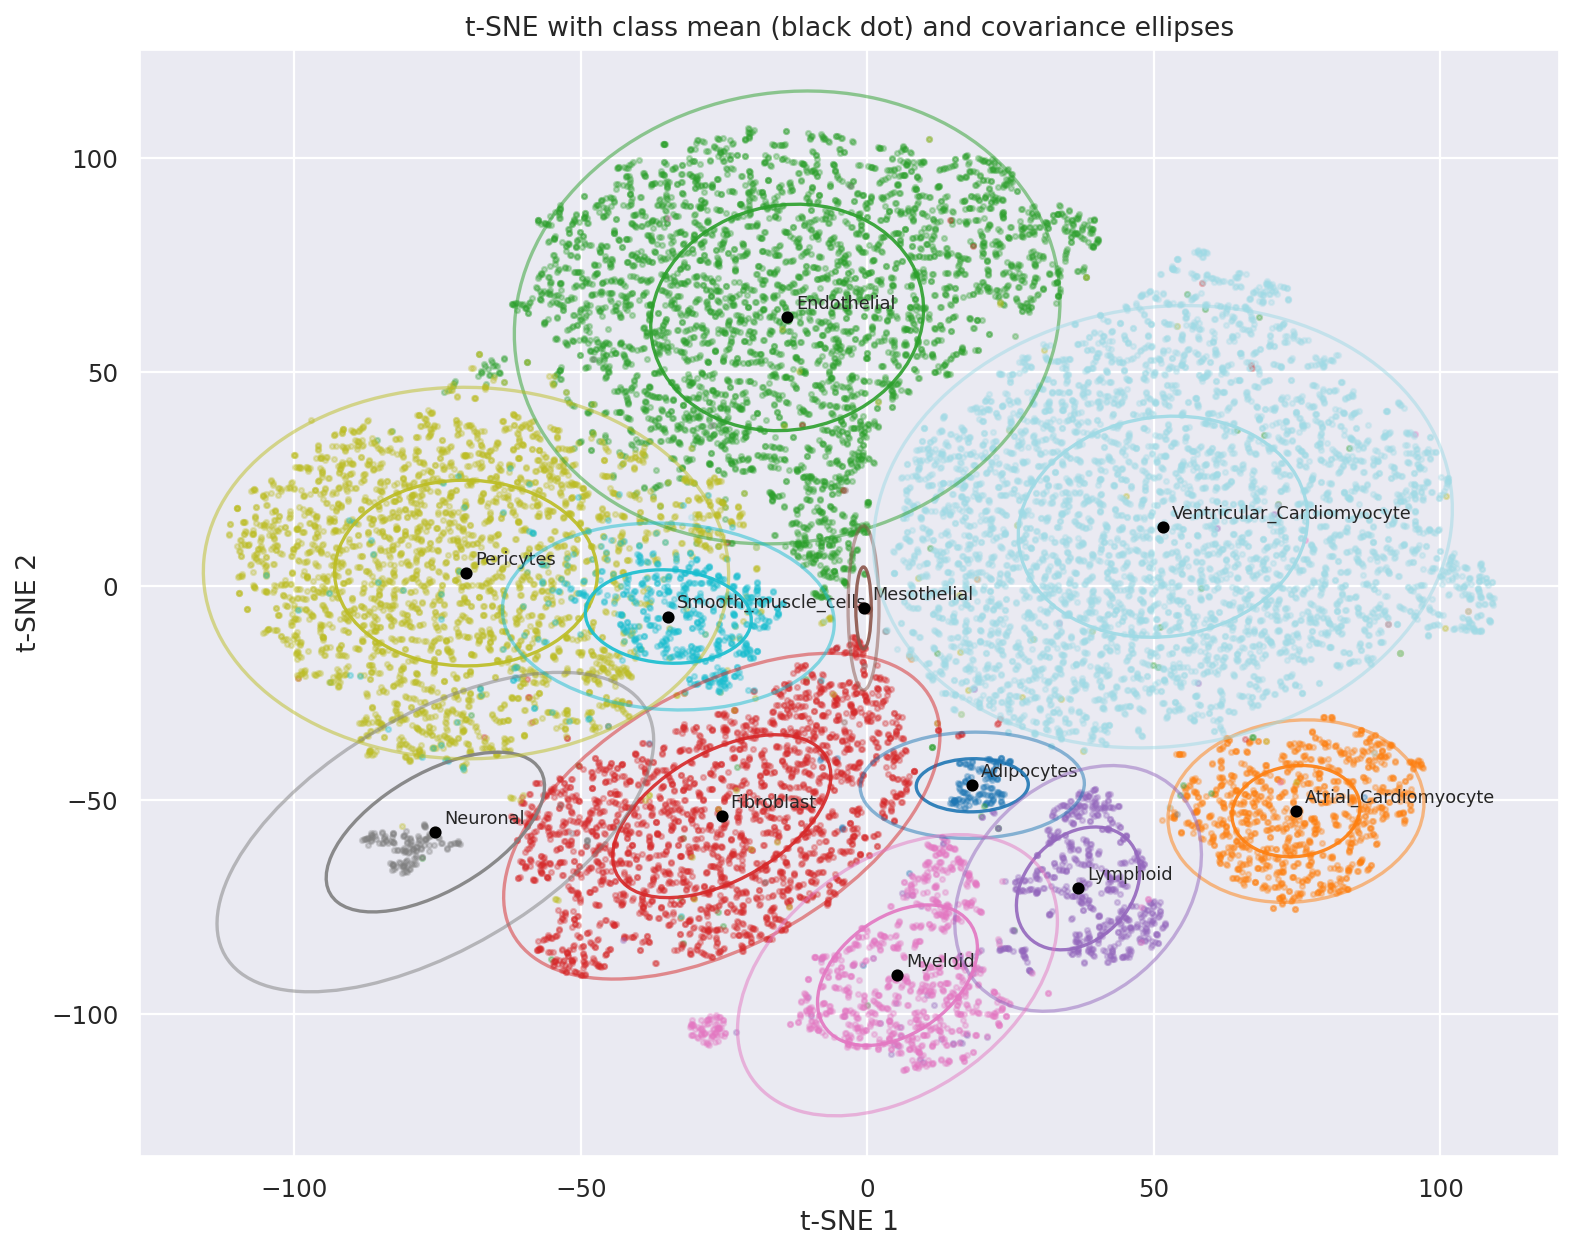

In [123]:
# Visualizing class representatives using mean (X_scVI) and covariance
import matplotlib.patches as mpatches

groupby = "cell_type"
categories = adata.obs[groupby].cat.categories

tsne_coords = adata.obsm["X_tsne"]

fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.tab20(np.linspace(0, 1, len(categories)))
color_map = dict(zip(categories, colors))

# Background points
for cat in categories:
    mask = adata.obs[groupby] == cat
    ax.scatter(
        tsne_coords[mask, 0],
        tsne_coords[mask, 1],
        c=[color_map[cat]],
        s=5,
        alpha=0.3
    )

# Foreground: mean + ellipse
for cat in categories:
    mask = adata.obs[groupby] == cat
    points = tsne_coords[mask]

    # Mean in t-SNE space
    mean = points.mean(axis=0)

    # Covariance in t-SNE space
    cov = np.cov(points.T)

    # Eigen decomposition
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    # Ellipse parameters
    n_std = 2.0
    width, height = 2 * np.sqrt(vals) # * n_std
    # width, height = 2 * n_std * np.sqrt(vals / np.sum(vals))
    # width, height = 2 * np.sqrt(vals)   # 2σ
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    # Small black mean dot
    ax.scatter(mean[0], mean[1], c='black', s=20, zorder=6)

    # Label
    ax.annotate(
        cat, mean,
        fontsize=8,
        xytext=(4, 4),
        textcoords='offset points'
    )

    # Ellipse
    # ellipse = mpatches.Ellipse(
    #     xy=mean,
    #     width=width,
    #     height=height,
    #     angle=angle,
    #     fill=False,
    #     edgecolor=color_map[cat],
    #     linewidth=2,
    #     alpha=0.9,
    #     zorder=5
    # )
    # ax.add_patch(ellipse)

    for n_std, alpha in [(1, 0.9), (2, 0.5)]:
      width, height = 2 * n_std * np.sqrt(vals)

      ellipse = mpatches.Ellipse(
          xy=mean,
          width=width,
          height=height,
          angle=angle,
          fill=False,
          edgecolor=color_map[cat],
          linewidth=1.5,
          alpha=alpha,
          zorder=5
      )
      ax.add_patch(ellipse)

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE with class mean (black dot) and covariance ellipses")

plt.tight_layout()
plt.show()

Continue improvements with context: https://chatgpt.com/c/69ea5396-d5b0-83eb-bfc7-a30f06d40b89

### Connecting code to paper

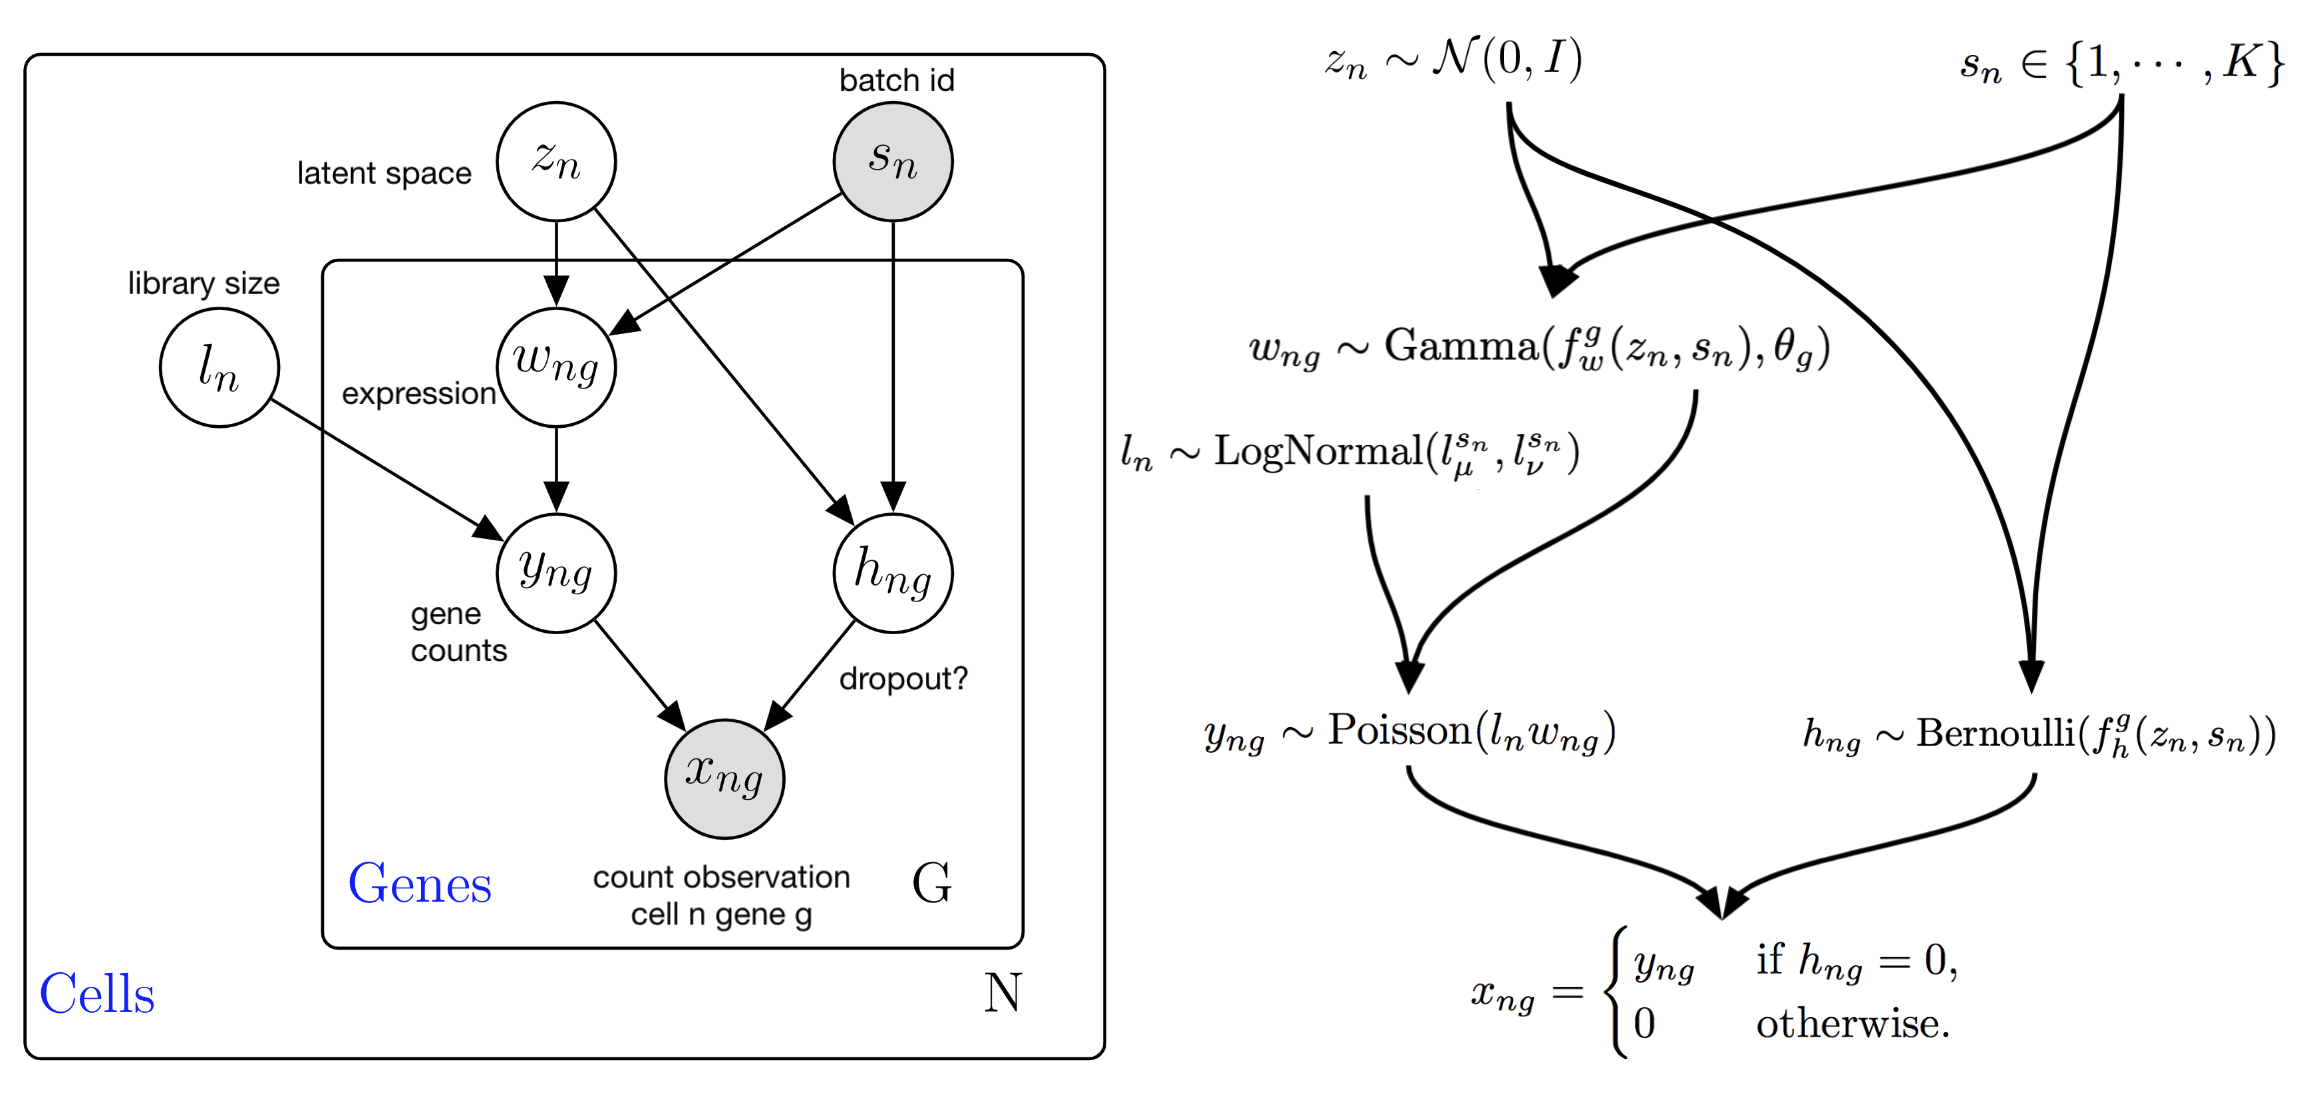

$$
\text{Count-based likelihood distribution}: x_{ng} \sim \text{Observation Model}(l_np_n, \theta_n, \pi_{ng})
$$

$$
\text{ Library Size}: l_n\sim \text{LogNormal}(l^{s_n}_\mu, l^{s_n}_\nu)
$$
Nuisance variable. Normalizes gene expression by setting a maximum value. If unknown, inferred as a latent variable.

In [64]:
library_size = model.get_latent_library_size(give_mean=False)
# give_mean=False samples from the posterior distribution
library_size
len(library_size) #18641
library_size.mean() #338.14694

np.float32(338.14694)

$$
\text{ Decoded Gene Expression (Related to gene-specific } ω_{ng} \text{)}   \\
p_n = f_w(z_n, s_n): \mathbb{R}^d \times \{0, 1\}^K \to \Delta^{G-1}
$$
Neural network that decodes denoised gene expression. Sums to 1 for each cell.

In [97]:
denoised = model.get_normalized_expression(adata, library_size=1e4)
denoised.iloc[:5, :5]

,ISG15,TNFRSF18,VWA1,HES5,SPSB1
AACTCCCCACGAGAGT-1-HCAHeart7844001,11.996126,0.056343,0.028730,0.047778,0.266519
ATAACGCAGAGCTGGT-1-HCAHeart7829979,1.326313,0.002805,0.185371,0.005011,0.433808
GTCAAGTCATGCCACG-1-HCAHeart7702879,0.847805,0.009302,1.240898,0.071630,3.077248
GGTGATTCAAATGAGT-1-HCAHeart8102858,22.372185,0.219977,5.668082,0.066731,1.455381
AGAGAATTCTTAGCAG-1-HCAHeart8102863,6.750364,7.335338,1.974184,0.094458,7.922981


$$
\text{Batch parameter(Related to gene-specific } ω_{ng} \text{)}: \theta_{ng}
$$
Unique parameter learned for gene/batch.


$$
\text{Decoder NN} : \pi_{ng}=f^g_h(z_n, s_n) \\
f_h(z_n, s_n): \mathbb{R}^d \times \{0, 1\}^K \to (0,1)^{T}  \\
\text{Related to Droupout } h_{ng}\sim \text{Bernoulli}(f^g_h(z_n, s_n))
$$
Neural network that decodes nonzero inflation probability if using ZINB.

$$
\text{Likelihood}: p(x|z)
$$
We can estimate the parameters of the likelihood


In [99]:
likelihood_param = model.get_likelihood_parameters()
# Returns three arrays for mean, dropout and dispersion - meaning?

We can also calculate the negative log likelihood of the data given the latent variables. This is the reconstruction loss.

In [ ]:
reconstruction_error = model.get_reconstruction_error(adata)
reconstruction_error # 272.3427 was maximized during training

$$
\text{Posterior predictive distribution}: p(\hat{x}|x)
$$
We can generate predictive samples from the posterior predictive distribution by first sampling `n_samples` times from posterior distribution `q(z|x)` then from likelihood `p(\hat{x}|z)` for each of these.

Returns sparse multidim. array `(n_obs, n_vars)`.


In [101]:
model.posterior_predictive_sample(adata, n_samples=2)

Format,gcxs
Data Type,float32
Shape,"(18641, 1200, 2)"
nnz,3146498
Density,0.07033103553099798
Read-only,True
Size,36.2M
Storage ratio,0.21
Compressed Axes,"(0,)"
